In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten

#Dense-It creates a fully connected neural network

#Flatten - convert 28 x 28 pixel image into 784 vectors

#Sequential - to create neural network layer by layers

In [3]:
# load mnist dataset

# it have already 60,000 training data and 10000 testing data

(X_train,Y_train),(X_test,y_test)=mnist.load_data()
# X_train - actual image, y_train - digit of it


In [4]:
print("X-Train images: ",X_train.shape)
print("Y-train labels: ",Y_train.shape)
print("X-Test images: ",X_test.shape)
print("y-test labels: ",y_test.shape)

X-Train images:  (60000, 28, 28)
Y-train labels:  (60000,)
X-Test images:  (10000, 28, 28)
y-test labels:  (10000,)


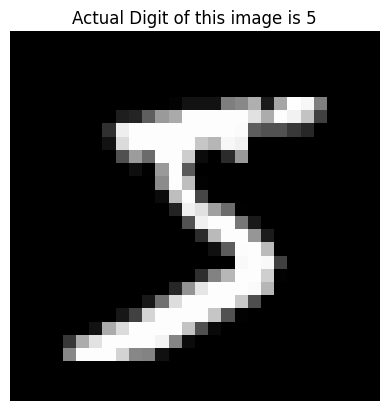

In [5]:
#let display one image
plt.imshow(X_train[0],cmap='gray')
plt.title(f"Actual Digit of this image is {Y_train[0]}")
plt.axis("off") #no x-y axis
plt.show()


In [8]:
#understand images pixel values
#before preprocessing, px are b/w 0-255

print("Min px value: ",X_train[0].min())
print("Max px value: ",X_train[0].max())

Min px value:  0
Max px value:  255


In [10]:
#Normalize the image, very important step

#convert 0-255 images into 0-1 range
X_train=X_train/255.0
X_test=X_test/255.0

print("Min px value: ",X_train[0].min())
print("Max px value: ",X_train[0].max())

#to divide by 255, max gray scale img px value is 255

Min px value:  0.0
Max px value:  0.00392156862745098


In [11]:
# Create an ANN model
model=Sequential([Flatten(input_shape=(28,28)),
                  Dense(128,activation='relu'),
                  Dense(64,activation='relu'),
                  Dense(10,activation='softmax')])

#Dense layer for 128 neurons, relu - max(0,x)-->take only positive value otherwise 0

#If it is 64 neurons, relu

#If it is 10 neurons at end,bcoz mnist contains classes (0-9)=10 digits, for it softmax ->predicts highest prob/-

#Relu - to make layers learn non-linear patterns

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
#configure how the model should learn

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

#adam--> decide and update weights for model to get crt result, if weight is low, then it is adjusted

#loss-->measures error

#'sparse_categorical_crossentropy' --> use for numerical values instead of one hot encoding
# bcoz, our dataset contains numeric values

#accuracy --> to show prediction accuracy of model

In [15]:
#Train the model

model.fit(X_train,Y_train,epochs=10,batch_size=32,validation_split=0.1)

#epochs - training times
#validation_split=0.1 means 10% of training data is used for validation

#batch_size--> for handling large dataset batch by batch to improve efficiency

#Eg: this dataset consists of 60,000 training data , to give training for each data is difficult

# instead use batch size as 32 means each batch is grouped by 32 data per batch,make training manageable

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7457 - loss: 0.8619 - val_accuracy: 0.8875 - val_loss: 0.3972
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8764 - loss: 0.4189 - val_accuracy: 0.9142 - val_loss: 0.3065
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8996 - loss: 0.3454 - val_accuracy: 0.9260 - val_loss: 0.2634
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9124 - loss: 0.3000 - val_accuracy: 0.9355 - val_loss: 0.2360
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9214 - loss: 0.2687 - val_accuracy: 0.9358 - val_loss: 0.2090
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9278 - loss: 0.2448 - val_accuracy: 0.9435 - val_loss: 0.1924
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9338 - loss: 0.2234 - val_accuracy: 0.9507 - val_loss: 0.1717
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9405 - loss: 0.204

In [16]:
#after training, evaluate the unseen data --> test data is evaluated here
loss,accuracy=model.evaluate(X_test,y_test)

print("Test Loss: ",loss)

print("Test Accuracy: ",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9481 - loss: 0.1764
Loss:  0.17636847496032715
Accuracy:  0.9480999708175659


In [18]:
#Make a prediction

predictions=model.predict(X_test) #generate prediction for test images

#for one image
prediction=predictions[0]

predicted_digit=np.argmax(prediction) #np.argmax() finds the position of the highest probability.
print("Predicted Image digit be : ",predicted_digit)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted Image digit be :  7


In [19]:
#compare actual vs predicted

actual_digit=y_test[0]
print("Actual digit: ",actual_digit)
print("Predicted digit: ",predicted_digit)

Actual digit:  7
Predicted digit:  7


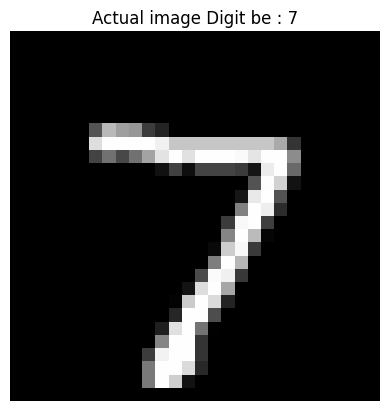

In [24]:
#let display predicted image
plt.imshow(X_test[0],cmap='gray')
plt.title(f"Actual image Digit be : {actual_digit}")
plt.axis("off")
plt.show()


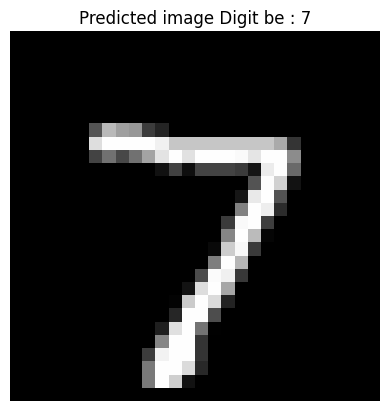

In [26]:
plt.imshow(X_test[0],cmap='gray')
plt.title(f"Predicted image Digit be : {predicted_digit}")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


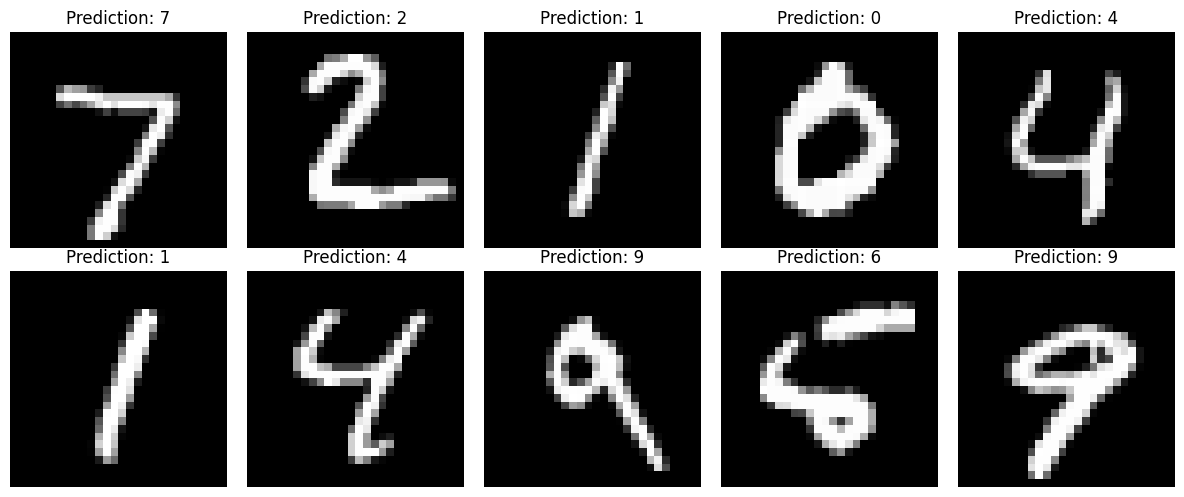

In [27]:
#Test multiple images - this displays 10 test images and their predicted output

plt.figure(figsize=(12,5))

for i in range(10):
  plt.subplot(2,5,i+1)#plt.subplot(rows,columns,incre)==> convert given 10 images into 2 rows 5 cols

  prediction=np.argmax(model.predict(X_test[i:i+1]))

  plt.imshow(X_test[i],cmap='gray')
  plt.title(f"Prediction: {prediction}")
  plt.axis("off")

plt.tight_layout()
plt.show()


Saving mnist2.png to mnist2 (2).png


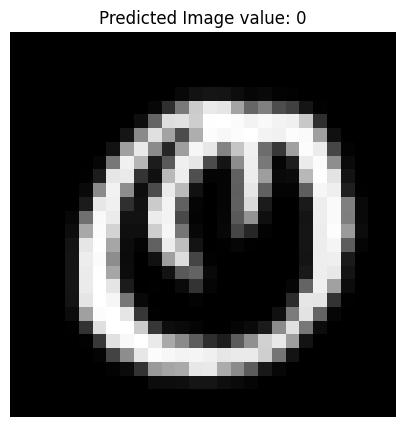

In [43]:
#Upload user entering digit img
from google.colab import files
from PIL import Image

uploaded=files.upload()

#filename
filename=list(uploaded.keys())[0]

#open file
image=Image.open(filename)

#convert into grayscale
image=image.convert('L')

#convert into resized image
image=image.resize((28,28))

#normalize mnist image px value
image_array=np.array(image)

image_array=image_array.astype('float')/255.0

#invert image if it has black on white background
if image_array.mean()>0.5: #if the avg image px is above 0.5 then it consider
  image_array=1-image_array

  '''
  Black → White
White → Black

Pixel|Meaning
0.0	- Black
0.5	- Gray
1.0	- White
'''

#add batch dimension
image_array=np.expand_dims(image_array,axis=0)#axis-0,for rows

#prediction
prediction=model.predict(image_array,verbose=0)
#verbose=0, silent prediction,dont show progress bar
predicted_digit=np.argmax(prediction)

#display image
plt.figure(figsize=(10,5))
plt.imshow(image_array[0],cmap='gray')
plt.title(f"Predicted Image value: {predicted_digit}")
plt.axis("off")
plt.show()

In [41]:
prediction = model.predict(image_array)

print(prediction)
print("Predicted digit:", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
[[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]
Predicted digit: 7
